# Lab 1 Task 2

In [1]:
!pip install thop
!pip install torchsummary

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import argparse
import os
import numpy as np
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter
from thop import profile
from torchsummary import summary

In [3]:
# Check if CUDA is available
print(torch.cuda.is_available())

True


In [4]:
# Calculate mean and std of dataset
def get_mean_std(dataset, ratio=1):
    # Get mean and std by sample ratio
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=int(len(dataset)*ratio), shuffle=True, num_workers=2)

    data = next(iter(dataloader))[0]     # get the first iteration data
    mean = np.mean(data.numpy(), axis=(0,2,3))
    std = np.std(data.numpy(), axis=(0,2,3))
    return mean, std

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_mean, train_std = get_mean_std(train_dataset)
test_mean, test_std = train_mean, train_std
print(train_mean, train_std)
print(test_mean, test_std)

[0.49139938 0.48215815 0.4465304 ] [0.24703284 0.2434853  0.26158866]
[0.49139938 0.48215815 0.4465304 ] [0.24703284 0.2434853  0.26158866]


In [5]:
##### data augmentation & normalization #####
transform_train = transforms.Compose([
    # 同學實作部分：Add data augmentation here
    transforms.ToTensor(),

    transforms.RandomCrop(32, padding=4),
    # data augmentation
    transforms.RandomHorizontalFlip(p = 0.5),
    
    
    #transforms.ToTensor(), # Transform to tensor
    transforms.Normalize(mean=train_mean, std=train_std), # Normalization
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=test_mean, std=test_std),
])

In [6]:
# Dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

image, label = trainset[0]
print("image shape: ", image.shape)

# Split validation dataset
torch.manual_seed(43)     # Ensure reproducibility
val_size = 5000       # Take 5000 images as validation set
train_size = len(trainset) - val_size
train_ds, val_ds = random_split(trainset, [train_size, val_size])
print("train length: ", len(train_ds))
print("val length: ", len(val_ds))
print("test length: ", len(test_ds))

# Declare batch size
# 學生實作部分：Set batch size
BATCH_SIZE = 500
trainloader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

image shape:  torch.Size([3, 32, 32])
train length:  45000
val length:  5000
test length:  10000


In [7]:
class BasicBlock(nn.Module):
    def __init__(self, inchannel, outchannel, stride=1):
        super(BasicBlock, self).__init__()
        self.left = nn.Sequential(
            nn.Conv2d(inchannel, outchannel, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
            nn.ReLU(inplace=True),
            nn.Conv2d(outchannel, outchannel, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(outchannel)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or inchannel != outchannel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inchannel, outchannel, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(outchannel)
            )

    def forward(self, x):
        out = self.left(x)
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, ResBlock, num_classes=10):
        super(ResNet18, self).__init__()
        self.inchannel = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1 = self.make_layer(ResBlock, 64, 2, stride=1)
        self.layer2 = self.make_layer(ResBlock, 128, 2, stride=2)
        self.layer3 = self.make_layer(ResBlock, 256, 2, stride=2)
        self.layer4 = self.make_layer(ResBlock, 512, 2, stride=2)
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)  # First block may have stride > 1, others stride=1
        layers = []
        for s in strides:
            layers.append(block(self.inchannel, channels, s))
            self.inchannel = channels  # Update inchannel for the next block
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [8]:
# Create SummaryWriter
writer = SummaryWriter("../tensorboard")

model = ResNet18(ResBlock=BasicBlock, num_classes=10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Print model summary
summary(model, (3, 32, 32))

# Calculate FLOPs and Params
dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input, ))
print(f"FLOPs: {flops/1e6:.2f} MFLOPs")
print(f"Params: {params/1e6:.2f} M")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          36,864
       BatchNorm2d-8           [-1, 64, 32, 32]             128
        BasicBlock-9           [-1, 64, 32, 32]               0
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
             ReLU-12           [-1, 64, 32, 32]               0
           Conv2d-13           [-1, 64, 32, 32]          36,864
      BatchNorm2d-14           [-1, 64,

In [9]:
# Setting parameter
EPOCH = 20
pre_epoch = 0
lr = 0.001


##### Train model #####

# 初始化模型損失函數與優化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr)
#scheduler = optimizer.step()


# 設定參數
best_model_path = 'best_model.pth'  # 模型保存路徑
best_val_accuracy = 0.0

# 用於記錄 loss 和 accuracy 的列表
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

val_accuracy = 0

# 訓練模型
for epoch in range(pre_epoch, EPOCH):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data in trainloader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # 初始化梯度
        optimizer.zero_grad()

        # 前向傳播
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 反向傳播與優化
        loss.backward()
        optimizer.step()

        # 累積損失
        running_loss += loss.item()

        # 計算訓練準確率
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_accuracy = 100. * correct / total

    # 記錄訓練損失和準確率
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch [{epoch+1}/{EPOCH}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | ")


    # 驗證模型
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in valloader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    if val_accuracy > best_val_accuracy:
      best_val_accuracy = val_accuracy
      torch.save(model.state_dict(), best_model_path)
    val_loss = val_loss / len(valloader)
    val_accuracy = 100. * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f"Epoch [{epoch+1}/{EPOCH}] "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")


print('Finished Training')
    




Epoch [1/20] Train Loss: 1.6659 | Train Acc: 38.67% | 
Epoch [1/20] Val Loss: 1.5566 | Val Acc: 43.50%
Epoch [2/20] Train Loss: 1.1476 | Train Acc: 58.35% | 
Epoch [2/20] Val Loss: 1.1529 | Val Acc: 59.60%
Epoch [3/20] Train Loss: 0.8866 | Train Acc: 68.11% | 
Epoch [3/20] Val Loss: 1.1498 | Val Acc: 62.74%
Epoch [4/20] Train Loss: 0.7555 | Train Acc: 73.42% | 
Epoch [4/20] Val Loss: 0.8630 | Val Acc: 70.48%
Epoch [5/20] Train Loss: 0.6413 | Train Acc: 77.38% | 
Epoch [5/20] Val Loss: 0.7831 | Val Acc: 73.88%
Epoch [6/20] Train Loss: 0.5618 | Train Acc: 80.48% | 
Epoch [6/20] Val Loss: 0.7848 | Val Acc: 73.04%
Epoch [7/20] Train Loss: 0.5032 | Train Acc: 82.52% | 
Epoch [7/20] Val Loss: 0.5834 | Val Acc: 79.62%
Epoch [8/20] Train Loss: 0.4536 | Train Acc: 84.16% | 
Epoch [8/20] Val Loss: 0.7510 | Val Acc: 75.98%
Epoch [9/20] Train Loss: 0.4133 | Train Acc: 85.65% | 
Epoch [9/20] Val Loss: 0.6902 | Val Acc: 77.86%
Epoch [10/20] Train Loss: 0.3775 | Train Acc: 86.81% | 
Epoch [10/20] Val

In [10]:
# Load the best model and evaluate on the test set
model.eval()

test_correct = 0
test_total = 0
with torch.no_grad():
    for test_inputs, test_labels in testloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)
        test_outputs = model(test_inputs)
        _, test_predicted = test_outputs.max(1)
        test_total += test_labels.size(0)
        test_correct += test_predicted.eq(test_labels).sum().item()
test_accuracy = 100. * test_correct / test_total
print(f"Best Model Test Accuracy: {test_accuracy:.2f}%")

Best Model Test Accuracy: 85.24%


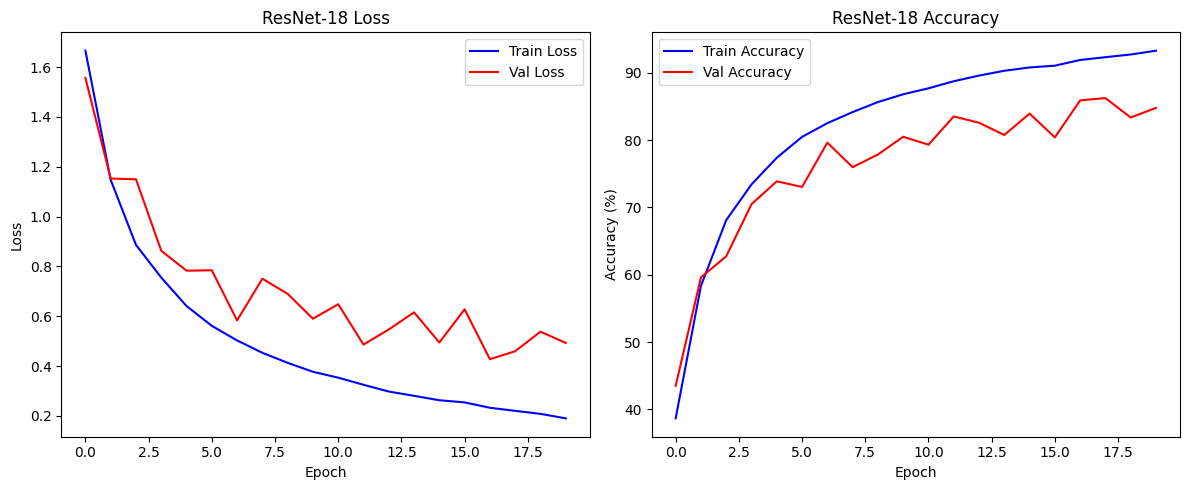

In [11]:
##### Plot loss & accuracy graph #####
import matplotlib.pyplot as plt
# 學生實作部分：Plot training and validation loss and accuracy curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(EPOCH), train_losses, 'b-', label='Train Loss')
plt.plot(range(EPOCH), val_losses, 'r-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet-18 Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH), train_accuracies, 'b-', label='Train Accuracy')
plt.plot(range(EPOCH), val_accuracies, 'r-', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('ResNet-18 Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
